In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class CounterState(TypedDict):
    count: int


def counter_node(state: CounterState):

    new_count = state["count"] + 1

    print(f"Current Count: {new_count}")

    return {"count": new_count}

def router(state: CounterState):

    if state["count"] < 5:
        return "repeat"

    return "stop"


graph = StateGraph(CounterState)

graph.add_node("counter_node", counter_node)

graph.add_edge(START, "counter_node")

graph.add_conditional_edges(
    "counter_node",
    router,
    {
        "repeat": "counter_node",
        "stop": END
    }
)


workflow = graph.compile()
result = workflow.invoke({"count": 0})

print(result)

Current Count: 1
Current Count: 2
Current Count: 3
Current Count: 4
Current Count: 5
{'count': 5}


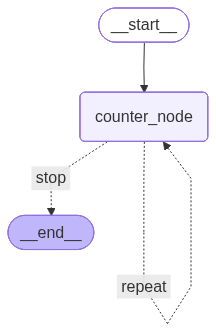

In [2]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())